Dataset shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

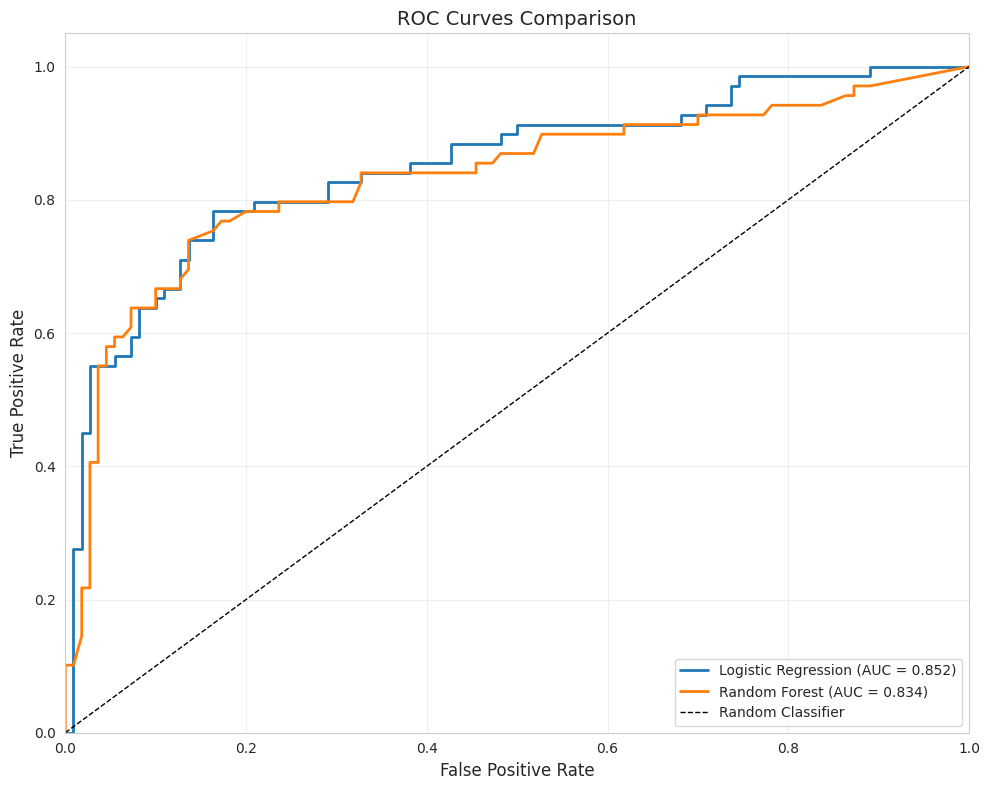

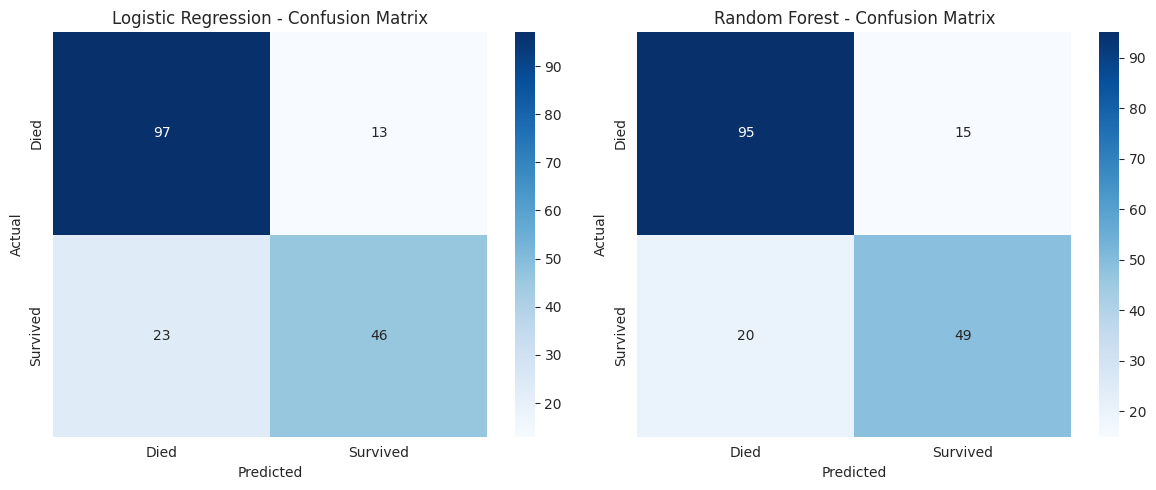

/tmp/ipykernel_149/1944190655.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')


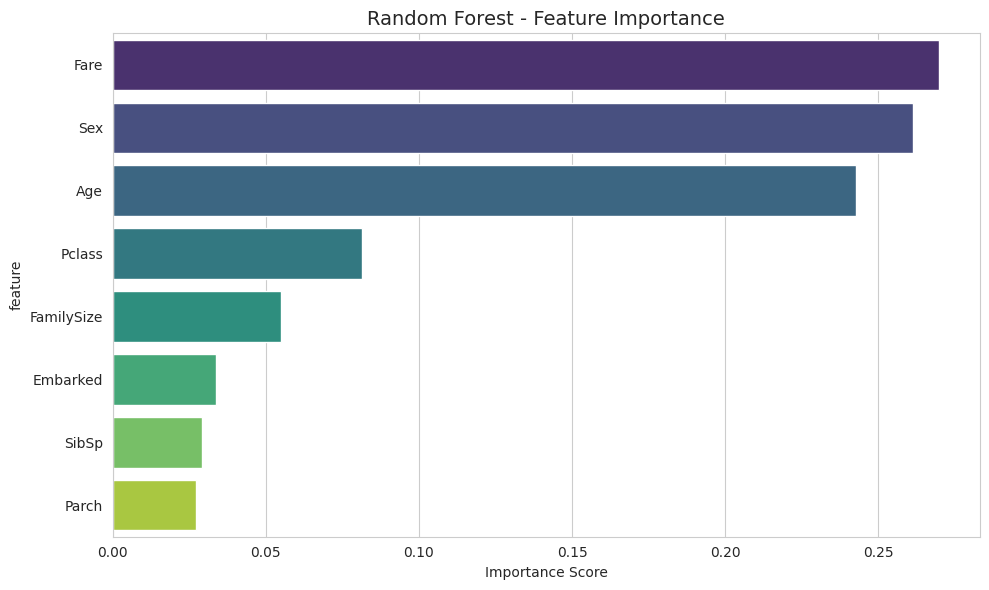

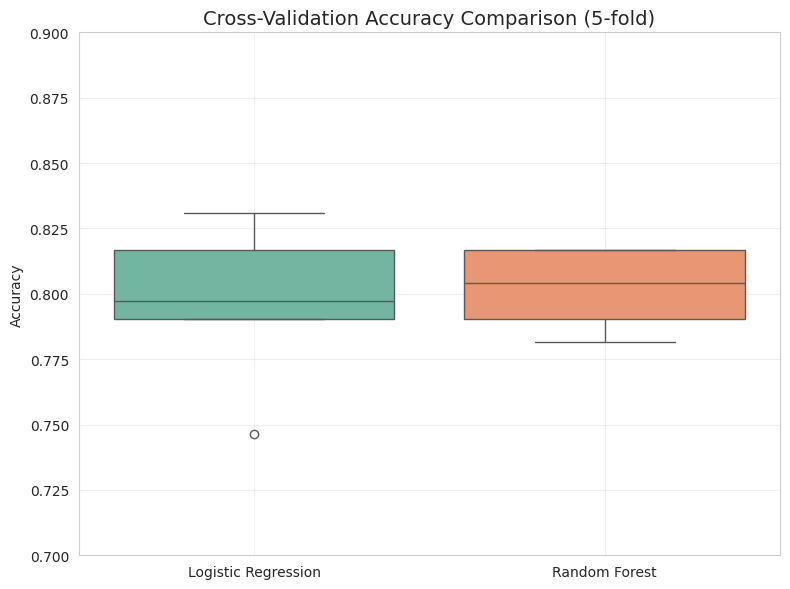


FINAL MODEL COMPARISON SUMMARY
   Metric  Logistic Regression  Random Forest
 Accuracy             0.798883       0.804469
Precision             0.779661       0.765625
   Recall             0.666667       0.710145
 F1-Score             0.718750       0.736842
  ROC-AUC             0.851910       0.833597

Cross-Validation (5-fold) Accuracy:
  Logistic Regression: 0.7964 (+/- 0.0288)
  Random Forest:        0.8020 (+/- 0.0141)


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             classification_report, confusion_matrix)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

def preprocess_titanic(df):
    """Clean and prepare Titanic dataset for modeling"""
    data = df.copy()
    
    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
    target = 'Survived'
    
    data = data.dropna(subset=[target])
    
    
    data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
    
    
    data['Age'] = data['Age'].fillna(data['Age'].median())
    
    
    data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
    
    
    le_sex = LabelEncoder()
    data['Sex'] = le_sex.fit_transform(data['Sex'])  # male=1, female=0
    
    le_embarked = LabelEncoder()
    data['Embarked'] = le_embarked.fit_transform(data['Embarked'])
    
    
    X = data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize']]
    y = data[target]
    
    return X, y

X, y = preprocess_titanic(df)
print(f"\nFeatures shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])


rf_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

models = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_pipeline
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = {
        'mean_accuracy': scores.mean(),
        'std_accuracy': scores.std(),
        'all_scores': scores
    }
    print(f"\n{name} - 5-fold CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")


test_results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    test_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\n{name} - Test Set Performance:")
    print(f"  Accuracy:  {test_results[name]['accuracy']:.4f}")
    print(f"  Precision: {test_results[name]['precision']:.4f}")
    print(f"  Recall:    {test_results[name]['recall']:.4f}")
    print(f"  F1-Score:  {test_results[name]['f1']:.4f}")
    print(f"  ROC-AUC:   {test_results[name]['roc_auc']:.4f}")


for name in models.keys():
    print(f"\n{name} - Classification Report:")
    print(classification_report(y_test, test_results[name]['y_pred'], 
                                target_names=['Died', 'Survived']))

plt.figure(figsize=(10, 8))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, test_results[name]['y_pred_proba'])
    auc = test_results[name]['roc_auc']
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test, test_results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Died', 'Survived'],
                yticklabels=['Died', 'Survived'])
    axes[idx].set_title(f'{name} - Confusion Matrix', fontsize=12)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

rf_model = models['Random Forest'].named_steps['classifier']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Random Forest - Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

cv_df = pd.DataFrame({
    'Logistic Regression': cv_results['Logistic Regression']['all_scores'],
    'Random Forest': cv_results['Random Forest']['all_scores']
})

plt.figure(figsize=(8, 6))
sns.boxplot(data=cv_df, palette='Set2')
plt.title('Cross-Validation Accuracy Comparison (5-fold)', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0.7, 0.9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150)
plt.show()

summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [test_results['Logistic Regression'][m] for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']],
    'Random Forest': [test_results['Random Forest'][m] for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
})

print("\n" + "="*60)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))

print("\nCross-Validation (5-fold) Accuracy:")
print(f"  Logistic Regression: {cv_results['Logistic Regression']['mean_accuracy']:.4f} (+/- {cv_results['Logistic Regression']['std_accuracy']:.4f})")
print(f"  Random Forest:        {cv_results['Random Forest']['mean_accuracy']:.4f} (+/- {cv_results['Random Forest']['std_accuracy']:.4f})")

In [2]:
pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 KB 6.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.
